In [2]:
from typing import TypedDict, Literal

class PortFolioState(TypedDict):
    amount_usd: float
    total_usd: float
    target_currency: Literal["EUR", "INR"]
    total: float


def calc_total(state: PortFolioState) -> PortFolioState:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def convert_to_inr(state: PortFolioState) -> PortFolioState:
    state['total'] = state['total_usd'] * 96.50
    return state

def convert_to_eur(state: PortFolioState) -> PortFolioState:
    state['total'] = state['total_usd'] * 0.9
    return state

def choose_conversion(state: PortFolioState) -> str:
    return state['target_currency']


from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortFolioState)

builder.add_node("calc_total_node", calc_total)
builder.add_node("convert_to_inr_node", convert_to_inr)
builder.add_node("convert_to_eur_node", convert_to_eur)

builder.add_edge(START, "calc_total_node")
builder.add_conditional_edges(
    "calc_total_node",
    choose_conversion,
    {
        "INR": "convert_to_inr_node",
        "EUR": "convert_to_eur_node",
    }
)

builder.add_edge(["convert_to_inr_node", "convert_to_eur_node"], END)

graph = builder.compile()


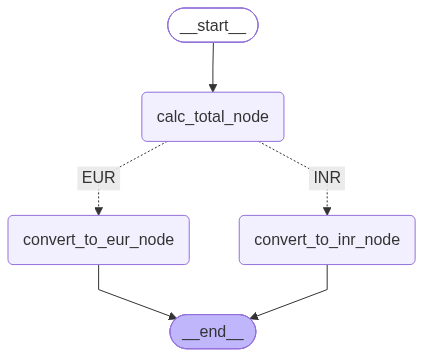

In [2]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
for currency in ["INR", "EUR"]:
    result = graph.invoke({'amount_usd': 1000, 'target_currency': currency})
    print(f"{currency}: {result}")


INR: {'amount_usd': 1000, 'total_usd': 1080.0, 'target_currency': 'INR', 'total': 104220.0}
EUR: {'amount_usd': 1000, 'total_usd': 1080.0, 'target_currency': 'EUR', 'total': 972.0}
